# **MACHINE LEARNING**
## **EDA — Prediciendo la Diabetes**


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

import joblib
import os

In [40]:
# Carga del dataset

csv_file_path = "/content/sample_data/diabetes.csv"
df = pd.read_csv(csv_file_path)

print(df.shape)
df.head(10)

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


Este dataset tiene 768 filas y 9 columnas, todas las variables son numéricas.

In [41]:
# 2.1 INFORMACIÓN GENERAL DEL DATASET

print(" INFORMACIÓN GENERAL DEL DATASET")
df.info()

 INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Vemos que el dataset no tiene ningun valor nulo. y que todas las columnas tienen valores de tipo numérico, tanto int como float.

In [42]:
# 2.2 ESTADÍSTICAS DESCRIPTIVAS

df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


`.describe()` nos muestra las estadísticas descriptivas de todas las columnas, vemos que hay varias columnas con mínimos de cero, algo que es imposible, no se puede tener `Glucose`, `BloodPressure`, `SkinThickness` por ejemplo, con valores cero. Esto nos indica **valores faltantes.**

In [43]:
# 2.3 VALORES NULOS

print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\n Total valores nulos: {df.isnull().sum().sum()}")

Valores nulos por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

 Total valores nulos: 0


Podemos observar que no tenemos **nungun valor nulo** en ninguna columna del dataset.

In [44]:
# 2.4 VALORES CERO (POTENCIALMENTE VALORES FALTANTES)

# En este dataset, ciertas columnas no deberían tener ceros fisiológicamente:
# Glucose, BloodPressure, SkinThickness, Insulin, BMI
cols_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Valores cero en columnas médicas (probables valores faltantes):")
for col in cols_con_ceros:
    ceros = (df[col] == 0).sum()
    pct = ceros / len(df) * 100
    print(f"   {col:30s} → {ceros:3d} ceros ({pct:.1f}%)")

Valores cero en columnas médicas (probables valores faltantes):
   Glucose                        →   5 ceros (0.7%)
   BloodPressure                  →  35 ceros (4.6%)
   SkinThickness                  → 227 ceros (29.6%)
   Insulin                        → 374 ceros (48.7%)
   BMI                            →  11 ceros (1.4%)


Vemos muchos ceros en las columnas SkinThickness y Insuline en ninguna de estas 5 columnas debería haber valor cero, ya que es biologicamente imposible.

In [45]:
# 2.5 TRATAMIENTO DE VALORES CERO → IMPUTACIÓN POR MEDIANA

df_clean = df.copy()

for col in cols_con_ceros:
    mediana = df_clean[col].replace(0, np.nan).median()
    df_clean[col] = df_clean[col].replace(0, mediana)
    print(f" {col}: 0s → mediana = {mediana:.2f}")

print("\nImputación completada")

 Glucose: 0s → mediana = 117.00
 BloodPressure: 0s → mediana = 72.00
 SkinThickness: 0s → mediana = 29.00
 Insulin: 0s → mediana = 125.00
 BMI: 0s → mediana = 32.30

Imputación completada


He cambiado las los valores **cero** de las columanas por su correspondiente mediana. Es importante reemplazar los valores cero, ya que nadie vivo puede tener la presion arterial = 0.

He usado la mediana en vez de la media porque resiste mejor los outliers, por ejemplo en `Insulin` vemos fuertes outliers, esto disparar'ia la media.

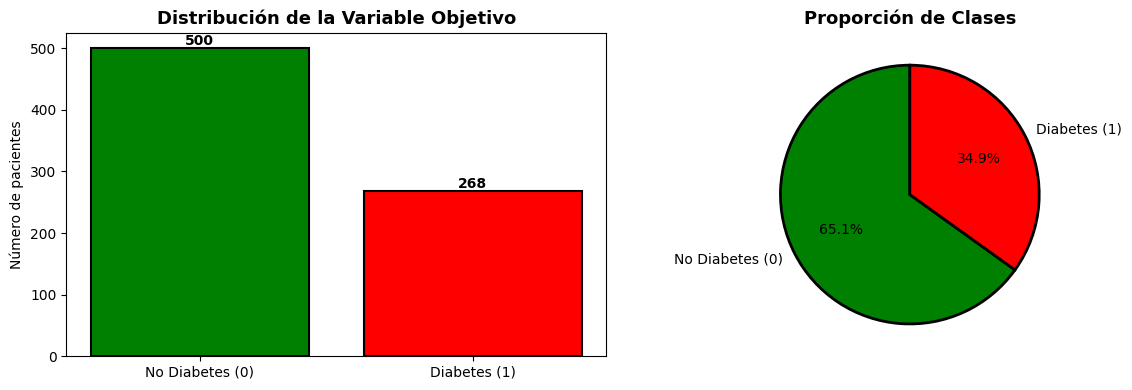


 Distribución:
   No Diabetes (0): 500 pacientes (65.1%)
   Diabetes    (1): 268 pacientes (34.9%)

 Hay cierto desbalance de clases (más negativos que positivos)


In [46]:
# 2.6 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
counts = df_clean['Outcome'].value_counts()
axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'],
            counts.values,
            color=['green', 'red'],
            edgecolor='black',
            linewidth=1.5)
axes[0].set_title('Distribución de la Variable Objetivo', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de pacientes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Porcentaje
axes[1].pie(counts.values,
            labels=['No Diabetes (0)', 'Diabetes (1)'],
            autopct='%1.1f%%',
            colors=['green', 'red'],
            startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 2})
axes[1].set_title('Proporción de Clases', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n Distribución:")
print(f"   No Diabetes (0): {counts[0]} pacientes ({counts[0]/len(df_clean)*100:.1f}%)")
print(f"   Diabetes    (1): {counts[1]} pacientes ({counts[1]/len(df_clean)*100:.1f}%)")
print("\n Hay cierto desbalance de clases (más negativos que positivos)")

Podemos observar un desbalance de clases, hay un 65% de No Diabetes vs un 35% de Diabetes. Es importnate mantener esta proporción en el modelo.




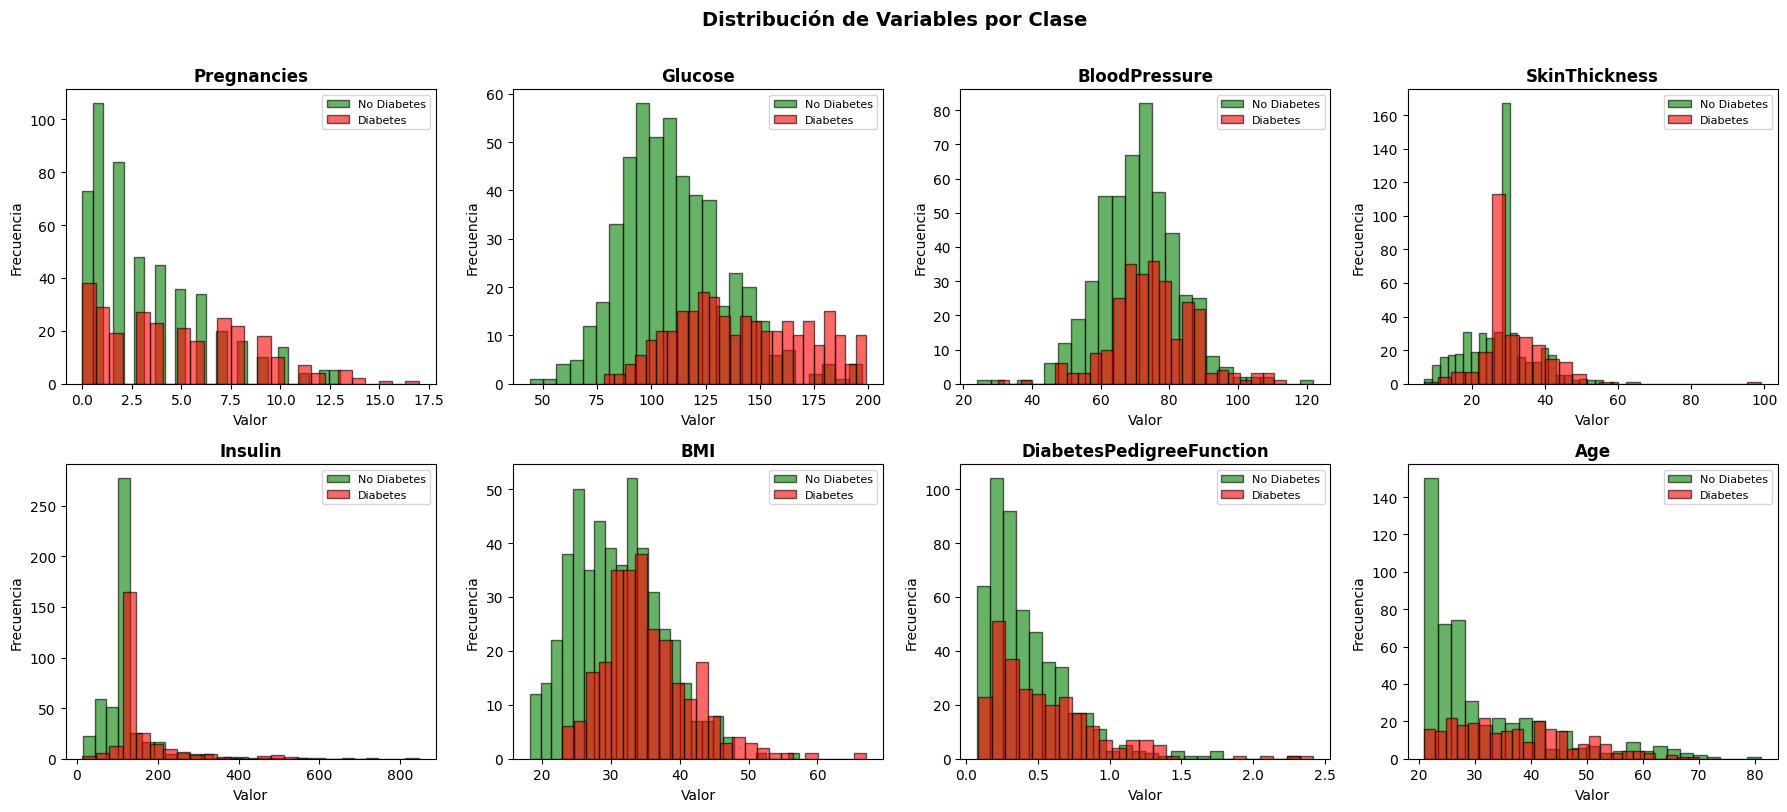

In [47]:
# 2.7 DISTRIBUCIÓN DE CADA VARIABLE

features = [c for c in df_clean.columns if c != 'Outcome']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df_clean[df_clean['Outcome'] == 0][col],
                 bins=25,
                 alpha=0.6,
                 color='green',
                 label='No Diabetes',
                 edgecolor='black')
    axes[i].hist(df_clean[df_clean['Outcome'] == 1][col],
                 bins=25,
                 alpha=0.6,
                 color='red',
                 label='Diabetes',
                 edgecolor='black')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables por Clase', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Estos histogramas superpuestos nos revelan que variables diferencian mejor diabeticos de no diabeticos:
- **Glucose**: obviamente la glucosa es el valor que más diferencia a dibeticos de no dibeticos.
- **BMI** y **Age**: También nos muestra claras diferencias.
- **SkinThickness** e **Insulin**: Muestran diferencias más leves.

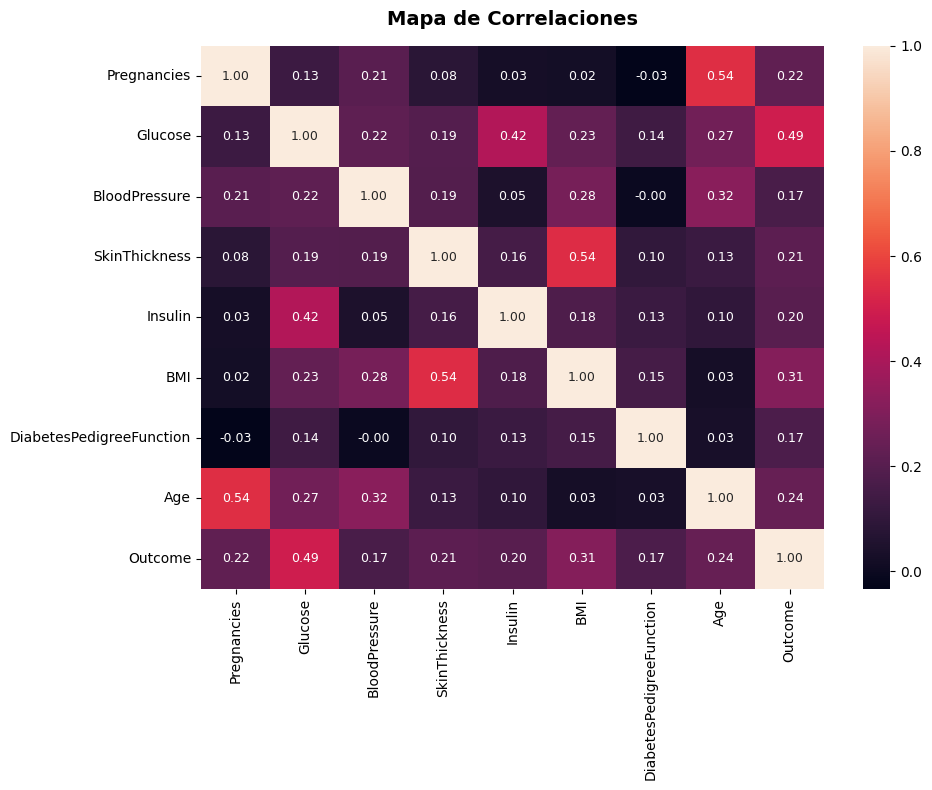

In [48]:
# 2.8 MAPA DE CORRELACIONES

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_clean.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            ax=ax,
            annot_kws={'size': 9})
ax.set_title('Mapa de Correlaciones', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Este heatmap nos confirma que la variable más correlacionada con `Outcome` es `Glucose` con casi un 0.50. Seguidas de `BMI`, `Age` y `Pregnancies`.

Las correlaciones en general son bajas, esto beneficia al decission tree.

/tmp/ipykernel_2294/1541366649.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_no, data_si],
/tmp/ipykernel_2294/1541366649.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_no, data_si],
/tmp/ipykernel_2294/1541366649.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_no, data_si],
/tmp/ipykernel_2294/1541366649.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_no, data_si],
/tmp

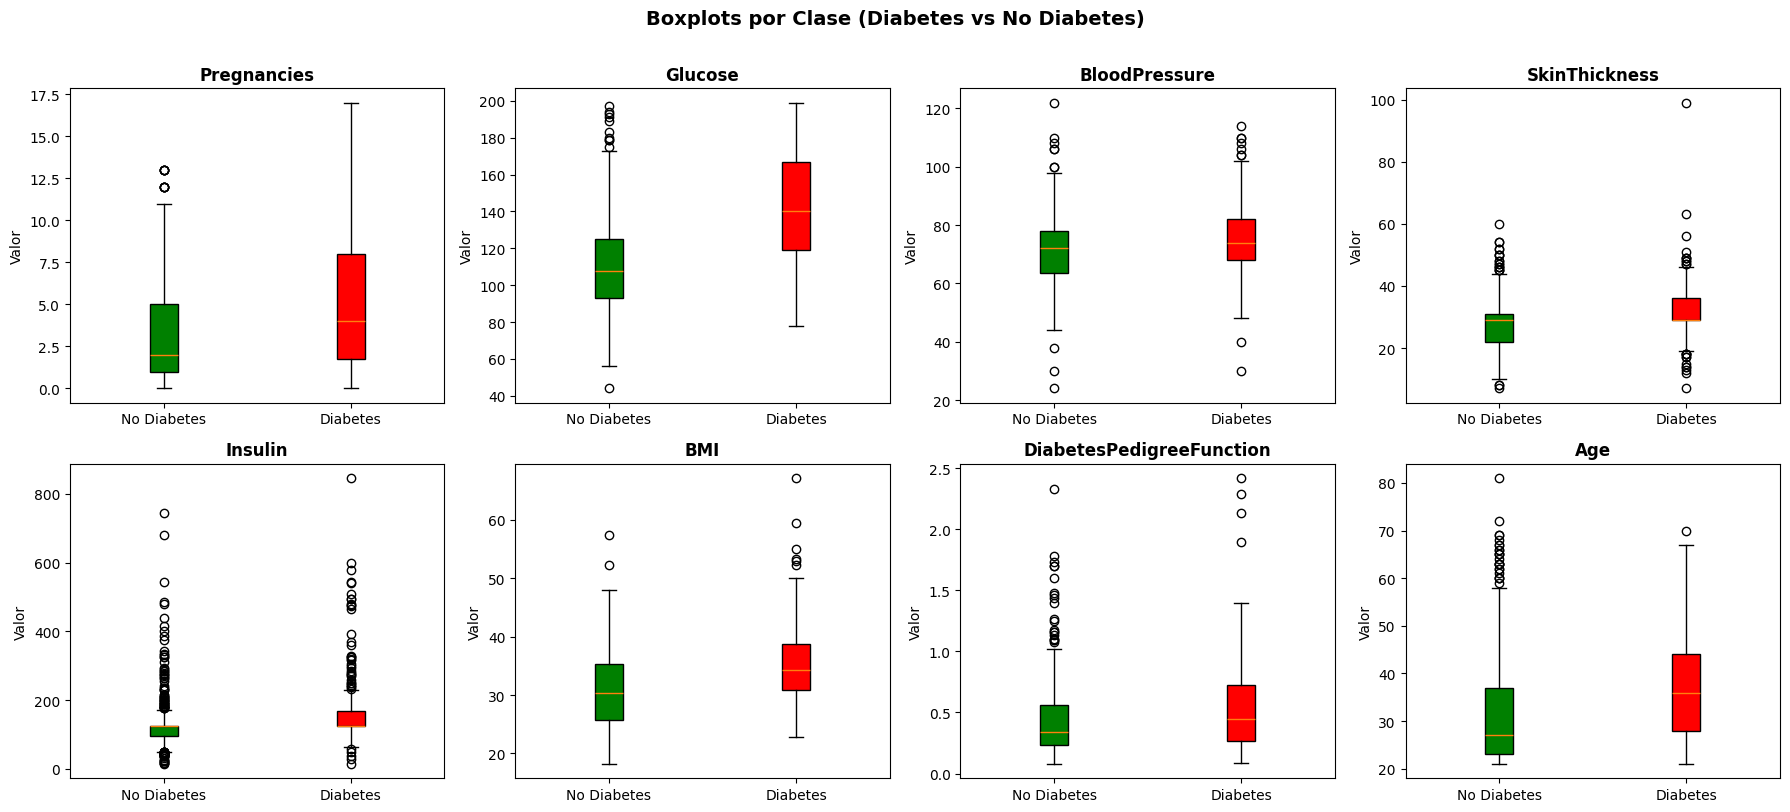

In [49]:
# 2.9 BOXPLOTS POR CLASE

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    data_no = df_clean[df_clean['Outcome'] == 0][col]
    data_si = df_clean[df_clean['Outcome'] == 1][col]
    bp = axes[i].boxplot([data_no, data_si],
                          patch_artist=True,
                          labels=['No Diabetes', 'Diabetes'])
    bp['boxes'][0].set_facecolor('green')
    bp['boxes'][1].set_facecolor('red')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Valor')

plt.suptitle('Boxplots por Clase (Diabetes vs No Diabetes)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Estos boxplots muestran **medianas, cuartiles y outliers** de cada variable, vamos a ver algunos.
- **Glucose**: la median de diabeticos esta por encima de la de no diabetcos.
- **Insulin** y **SkinThickness**: podemos apreciar muchos outliers.
- Aunque hay diferencias, vemos que no hay demasiada en **BloodPreasure**.

Top 5 variables más correlacionadas con Outcome: ['Glucose', 'BMI', 'Age', 'Pregnancies', 'SkinThickness']


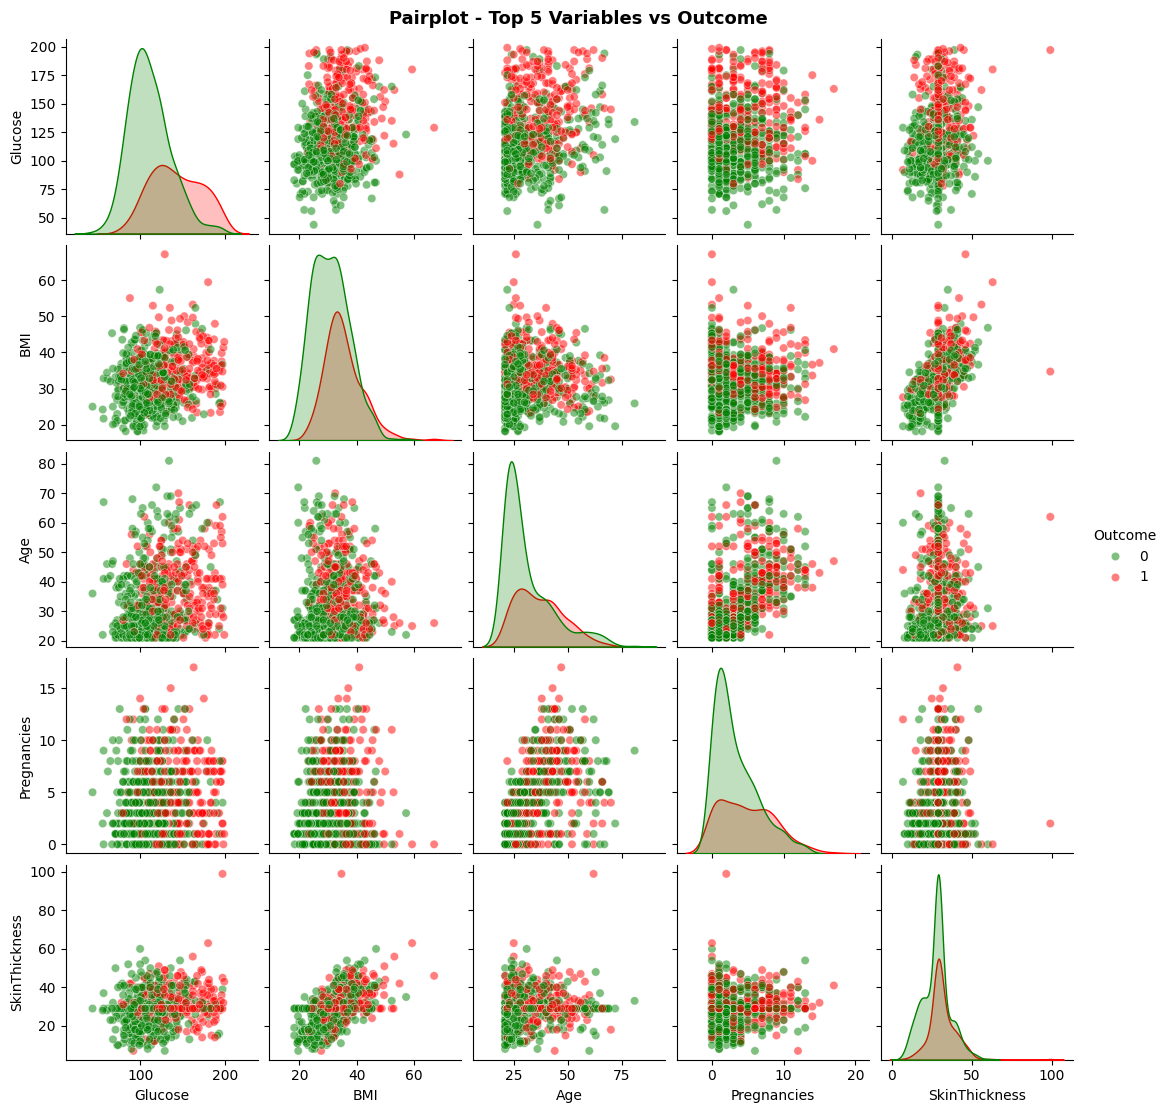

In [50]:
# 2.10 PAIRPLOT DE VARIABLES MÁS RELEVANTES

corr_target = df_clean.corr()['Outcome'].drop('Outcome').abs().sort_values(ascending=False)
top_features = corr_target.head(5).index.tolist() + ['Outcome']
print(f"Top 5 variables más correlacionadas con Outcome: {top_features[:-1]}")

sns.pairplot(df_clean[top_features],
             hue='Outcome',
             palette={0: 'green', 1: 'red'},
             height=2.2,
             plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot - Top 5 Variables vs Outcome', y=1.01, fontsize=13, fontweight='bold')
plt.show()

El pairplot es un gráfico que cruza cada variable con `Outcome`, podemos apreciar que el par `Glucose + BMI` muestra la mayor separación visual.

In [51]:
# 2.11 DETECCIÓN DE OUTLIERS (IQR)

print("Detección de outliers por columna (método IQR):")
for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)).sum()
    pct = outliers / len(df_clean) * 100
    print(f"  {col:30s}: {outliers:3d} outliers ({pct:.1f}%)")

print("\n Nota: Los outliers se mantienen ya que en datos médicos pueden ser clínicamente relevantes.")

Detección de outliers por columna (método IQR):
  Pregnancies                   :   4 outliers (0.5%)
  Glucose                       :   0 outliers (0.0%)
  BloodPressure                 :  14 outliers (1.8%)
  SkinThickness                 :  87 outliers (11.3%)
  Insulin                       : 346 outliers (45.1%)
  BMI                           :   8 outliers (1.0%)
  DiabetesPedigreeFunction      :  29 outliers (3.8%)
  Age                           :   9 outliers (1.2%)

 Nota: Los outliers se mantienen ya que en datos médicos pueden ser clínicamente relevantes.


Se puede apreciar que `Insulin` es la variable con mayor porcenatje de outliers, seguido de `SkinThickness` y `DiabetesPedigreeFunction`, los árboles de decisión trabajan bien los outliers y no se ven aectados por valores extremos.

##CONCLUSIONES DEL EDA
1. El dataset tiene 768 muestras y 9 variables, sin valores nulos.
2. He detectado valores cero en columnas médicas (Glucose, BloodPressure,
   SkinThickness, Insulin, BMI) cambiados por la mediana.
3. Hay desbalance de clases: 65% No Diabetes / 35% Diabetes.
4. Las variables con mayor correlación con Outcome son:
   1. Glucose (la más importante)
   2. BMI
   3. Age
   4. Pregnancies
   5. DiabetesPedigreeFunction
5. No hay variables con correlación alta entre sí, no hay
   multicolinealidad grave.


# **PASO 3: Construcción del Árbol de Decisión**

## Tipo de árbol a utilizar

Como que la variable objetivo `Outcome` es **binaria (0 o 1)**, voy a utilizar  un **árbol de clasificación** (`DecisionTreeClassifier`), no un árbol de regresión.

### Funciones de impureza disponibles en Scikit-learn:


**`gini`** - Índice de Gini: mide con qué frecuencia se clasificaría incorrectamente un elemento aleatorio. Rango [0, 0.5].

**`entropy`** - Entropía (Shannon): mide el desorden/aleatoriedad. Usa logaritmos. Rango [0, 1].

**`log_loss`** - Log Loss (Cross-Entropy): igual que entropía pero normalizada. Penaliza predicciones con alta confianza errónea.

In [52]:
# 3.0 SPLIT TRAIN / TEST

# Separo las features (X) de la variable objetivo (y)
X = df_clean.drop('Outcome', axis=1)   # Todas las columnas menos la que voy predecir
y = df_clean['Outcome']                 # Variable objetivo: 0 = No Diabetes, 1 = Diabetes

# Dividimos el dataset en entrenamiento (80%) y prueba (20%)
# random_state=42 garantiza reproducibilidad (misma división siempre)
# stratify=y asegura que la proporción de clases (65%/35%) se conserve en ambos splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Mantiene la proporción de clases en ambos splits
)

print(f" División del dataset (stratified split):")
print(f"   Train → {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test  → {X_test.shape[0]} muestras  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n   Proporción Outcome en Train: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"   Proporción Outcome en Test:  {y_test.value_counts(normalize=True).round(3).to_dict()}")

 División del dataset (stratified split):
   Train → 614 muestras (80%)
   Test  → 154 muestras  (20%)

   Proporción Outcome en Train: {0: 0.651, 1: 0.349}
   Proporción Outcome en Test:  {0: 0.649, 1: 0.351}


In [53]:
# 3.1 ENTRENAMIENTO CON LAS TRES FUNCIONES DE PUREZA
# Comparo los tres criterios de impureza para ver cuál rinde mejor sin optimizar

criterions = ['gini', 'entropy', 'log_loss']   # Las tres funciones de impureza disponibles
results = {}                                     # Diccionario para guardar métricas de cada modelo

for crit in criterions:
    # Creo un árbol sin restricciones (sin poda) para cada criterio
    tree = DecisionTreeClassifier(criterion=crit, random_state=42)
    tree.fit(X_train, y_train)   # Se entrena el modelo con los datos de entrenamiento

    # Generama predicciones sobre el conjunto de test
    y_pred = tree.predict(X_test)

    # Calcula accuracy en test
    acc = accuracy_score(y_test, y_pred)

    # Validación cruzada con 5 folds: entrena/valida 5 veces en distintos subconjuntos
    # Esto nos dara una estimación más fuerte del rendimiento real del modelo
    cv_scores = cross_val_score(tree, X, y, cv=5, scoring='accuracy')

    # Guardo todos los resultados en el diccionario para usarlos luego
    results[crit] = {
        'model': tree,               # El modelo entrenado
        'y_pred': y_pred,            # Predicciones sobre test
        'accuracy_test': acc,        # Accuracy en test
        'cv_mean': cv_scores.mean(), # Media de la validación cruzada
        'cv_std': cv_scores.std(),   # Desviación estándar del CV (variabilidad)
        'depth': tree.get_depth(),   # Profundidad máxima que alcanzó el árbol
        'leaves': tree.get_n_leaves() # Número total de hojas del árbol
    }
    print(f"\n Criterio: {crit.upper()}")
    print(f"   Accuracy Test:    {acc:.4f}")
    print(f"   CV Accuracy:      {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"   Profundidad:      {tree.get_depth()}")
    print(f"   Hojas:            {tree.get_n_leaves()}")


 Criterio: GINI
   Accuracy Test:    0.6818
   CV Accuracy:      0.7111 ± 0.0507
   Profundidad:      14
   Hojas:            111

 Criterio: ENTROPY
   Accuracy Test:    0.6753
   CV Accuracy:      0.6836 ± 0.0310
   Profundidad:      22
   Hojas:            106

 Criterio: LOG_LOSS
   Accuracy Test:    0.6753
   CV Accuracy:      0.6836 ± 0.0310
   Profundidad:      22
   Hojas:            106


In [54]:
# 3.2 CLASSIFICATION REPORTS COMPLETOS
# El classification report nos muestra precisión, recall y F1-score por clase
# Más informativo que el accuracy solo, sobre todo con clases desbalanceadas

for crit in criterions:
    print(f" Criterio: {crit.upper()}")
    # classification_report calcula métricas para cada clase por separado
    # target_names añade etiquetas en lugar de 0 y 1
    print(classification_report(y_test, results[crit]['y_pred'],
                                 target_names=['No Diabetes', 'Diabetes']))

 Criterio: GINI
              precision    recall  f1-score   support

 No Diabetes       0.74      0.79      0.76       100
    Diabetes       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154

 Criterio: ENTROPY
              precision    recall  f1-score   support

 No Diabetes       0.75      0.76      0.75       100
    Diabetes       0.54      0.52      0.53        54

    accuracy                           0.68       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.67      0.68      0.67       154

 Criterio: LOG_LOSS
              precision    recall  f1-score   support

 No Diabetes       0.75      0.76      0.75       100
    Diabetes       0.54      0.52      0.53        54

    accuracy                           0.68       154
   macro avg       0.64      0.64      0.64       154
weighted avg       

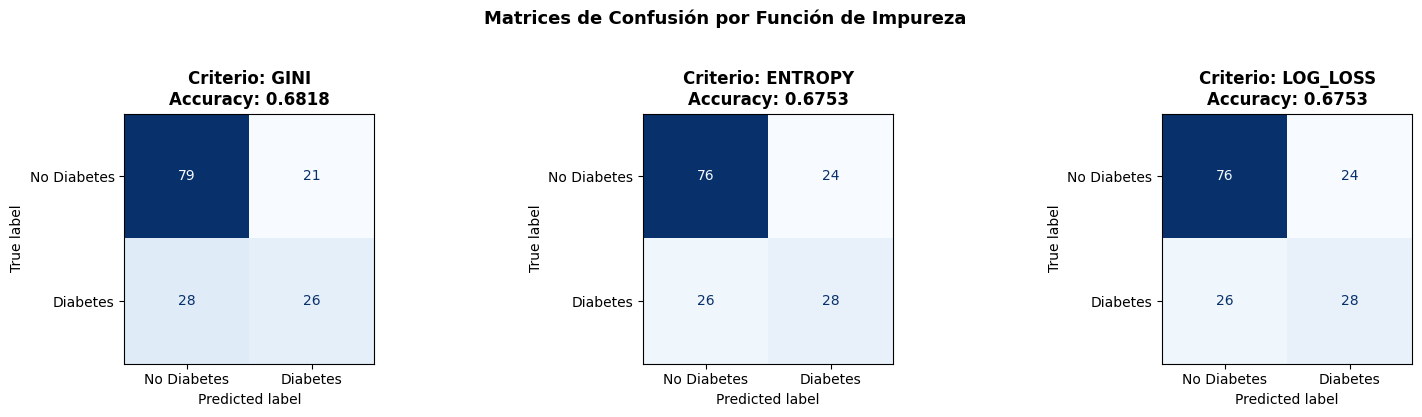

In [55]:
# 3.3 MATRICES DE CONFUSIÓN
# La matriz de confusión nos muestra cuántas predicciones fueron correctas e incorrectas
# por clase: Verdaderos Positivos, Falsos Positivos, Verdaderos Negativos, Falsos Negativos

fig, axes = plt.subplots(1, 3, figsize=(16, 4))   # Un subplot por cada criterio

for i, crit in enumerate(criterions):
    # Calcula la matriz de confusión comparando valores reales vs predichos
    cm = confusion_matrix(y_test, results[crit]['y_pred'])

    # ConfusionMatrixDisplay genera la visualización estándar de la matriz
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Diabetes', 'Diabetes'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'Criterio: {crit.upper()}\nAccuracy: {results[crit]["accuracy_test"]:.4f}',
                      fontweight='bold')

plt.suptitle('Matrices de Confusión por Función de Impureza', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

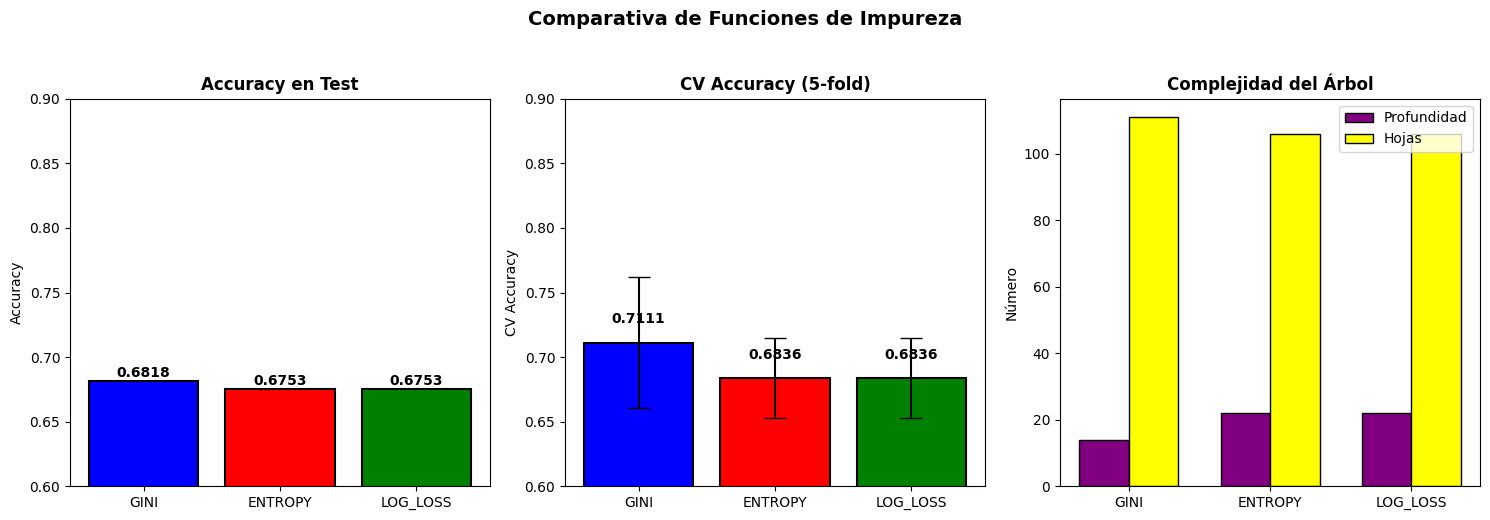

In [56]:
# 3.4 COMPARATIVA VISUAL DE MÉTRICAS
# Compara los tres criterios en tres gráficos: accuracy test, CV accuracy y complejidad del árbol

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

labels = [c.upper() for c in criterions]
colors = ['blue', 'red', 'green']

# --- Gráfico 1: Accuracy en Test ---
acc_vals = [results[c]['accuracy_test'] for c in criterions]
axes[0].bar(labels,
            acc_vals,
            color=colors,
            edgecolor='black',
            linewidth=1.5)
axes[0].set_title('Accuracy en Test', fontweight='bold')
axes[0].set_ylim([0.6, 0.9])
axes[0].set_ylabel('Accuracy')
for j, v in enumerate(acc_vals):
    axes[0].text(j, v + 0.003, f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)

# --- Gráfico 2: CV Accuracy con barras de error ---
# yerr muestra la desviación estándar
cv_vals = [results[c]['cv_mean'] for c in criterions]
cv_stds = [results[c]['cv_std'] for c in criterions]
axes[1].bar(labels,
            cv_vals,
            color=colors,
            edgecolor='black',
            linewidth=1.5,
            yerr=cv_stds,
            capsize=8)
axes[1].set_title('CV Accuracy (5-fold)', fontweight='bold')
axes[1].set_ylim([0.6, 0.9])
axes[1].set_ylabel('CV Accuracy')
for j, v in enumerate(cv_vals):
    axes[1].text(j, v + 0.015, f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)

# --- Gráfico 3: Complejidad del árbol (profundidad y número de hojas) ---
# Un árbol más profundo y con más hojas tiende a overfitting
depths = [results[c]['depth'] for c in criterions]
leaves = [results[c]['leaves'] for c in criterions]
x = np.arange(len(labels))
width = 0.35
axes[2].bar(x - width/2,
            depths,
            width,
            label='Profundidad',
            color='purple',
            edgecolor='black')
axes[2].bar(x + width/2,
            leaves,
            width,
            label='Hojas',
            color='yellow',
            edgecolor='black')
axes[2].set_title('Complejidad del Árbol', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].legend()
axes[2].set_ylabel('Número')

plt.suptitle('Comparativa de Funciones de Impureza', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


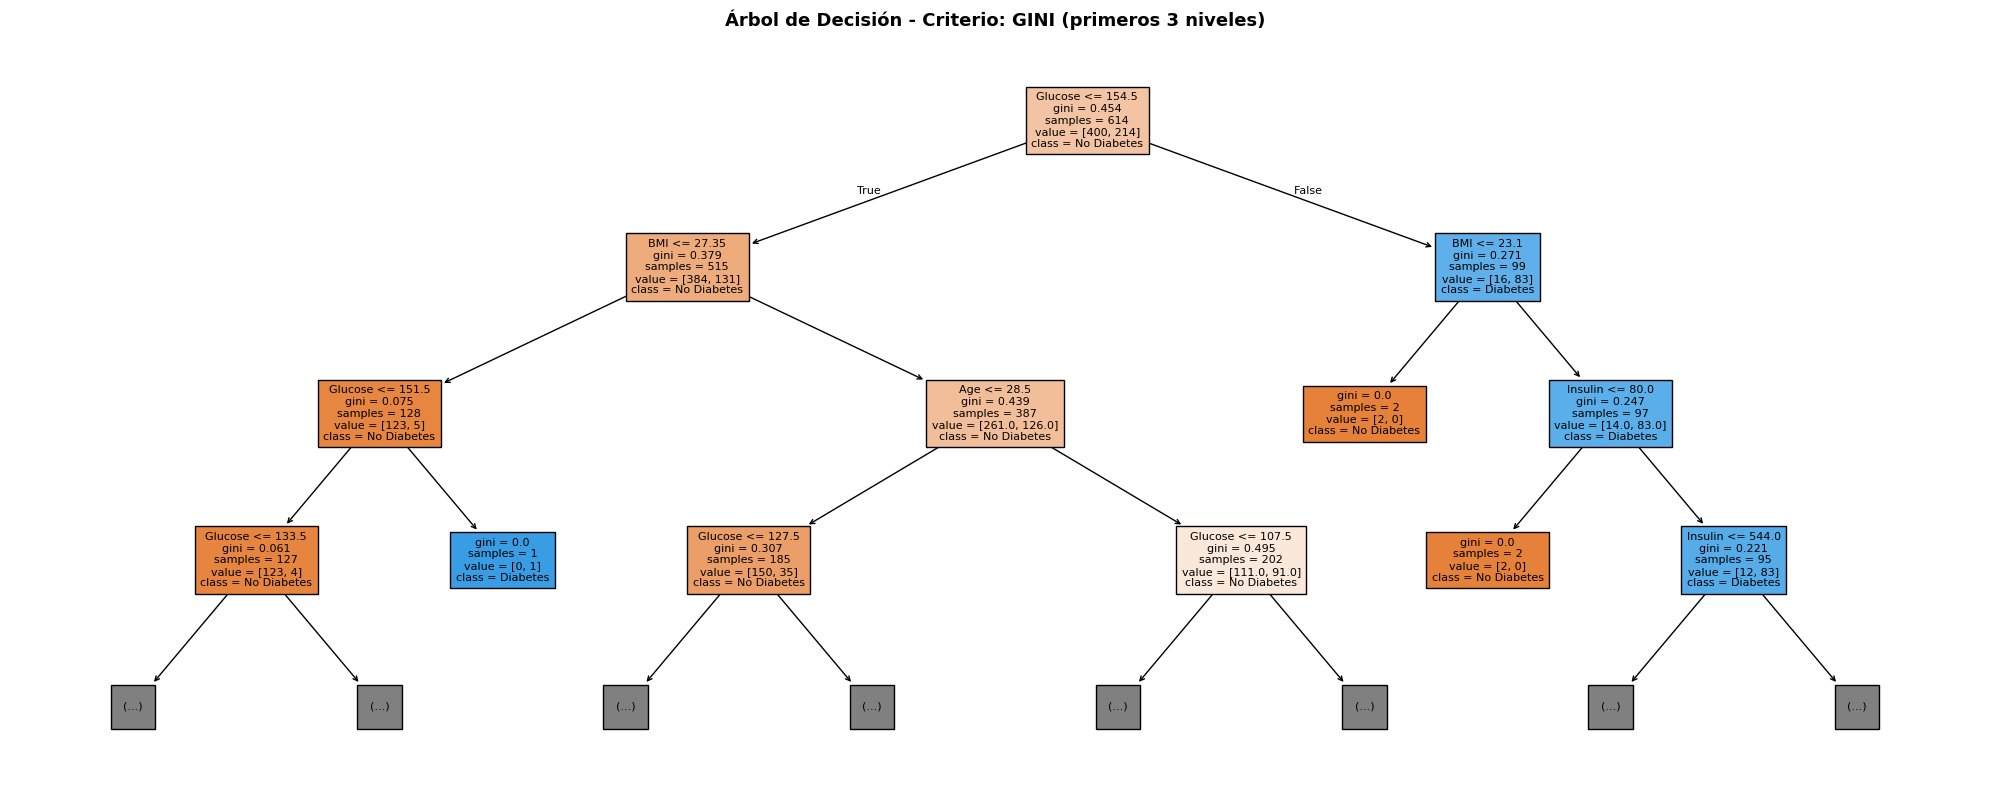

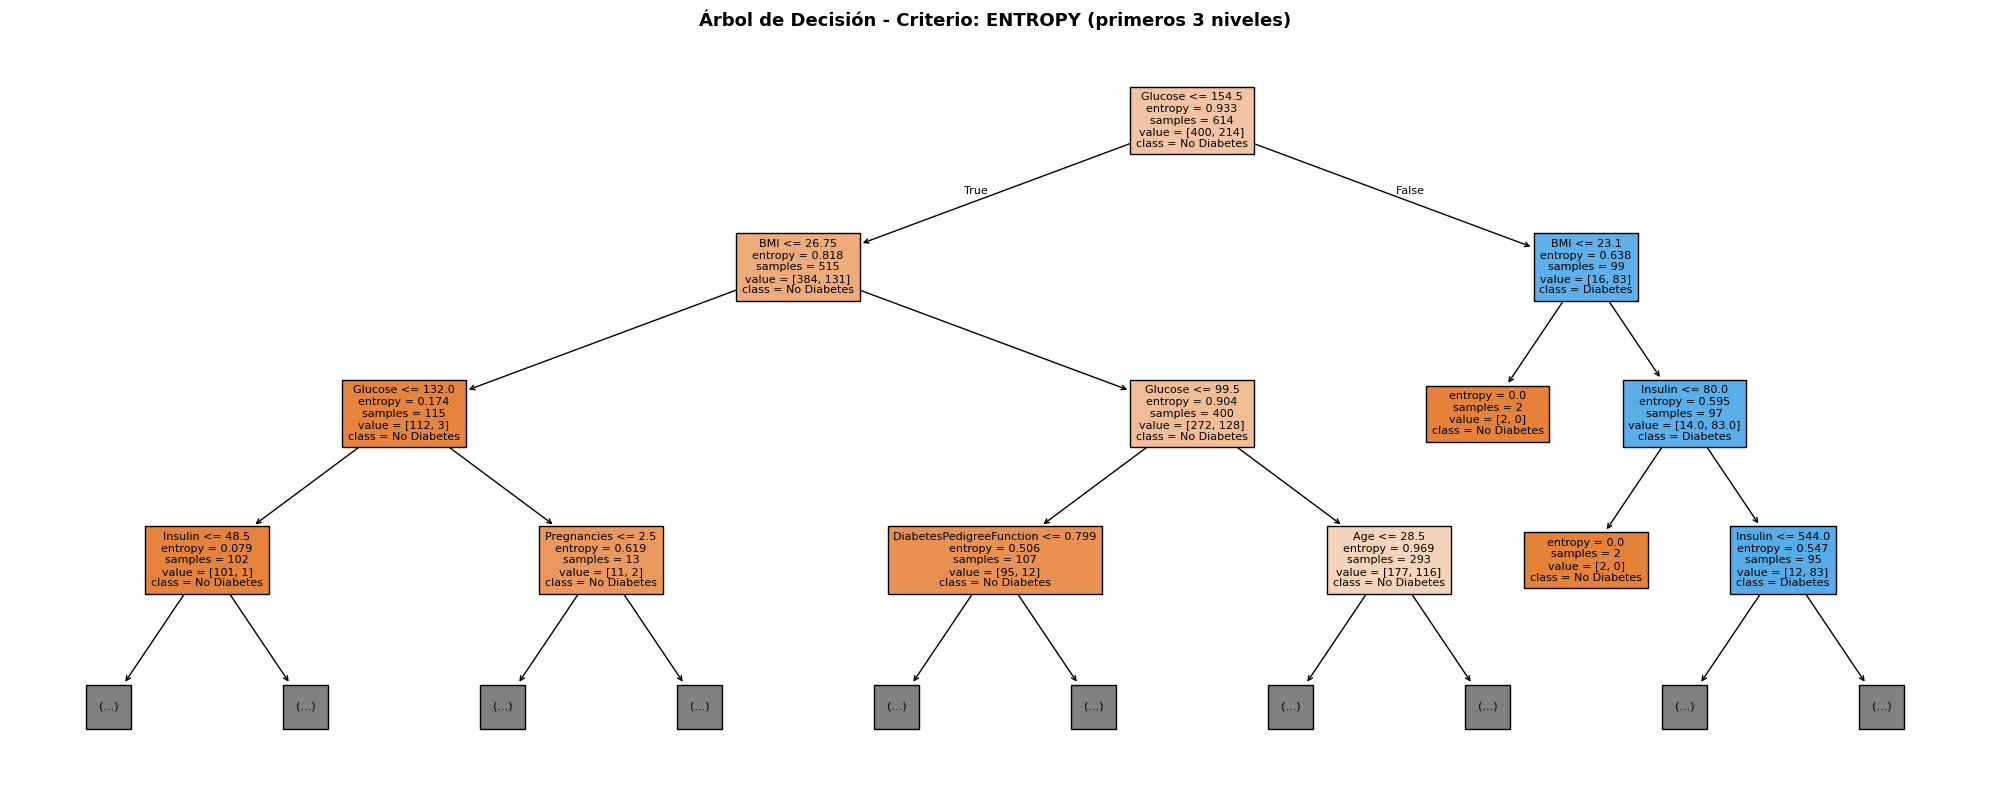

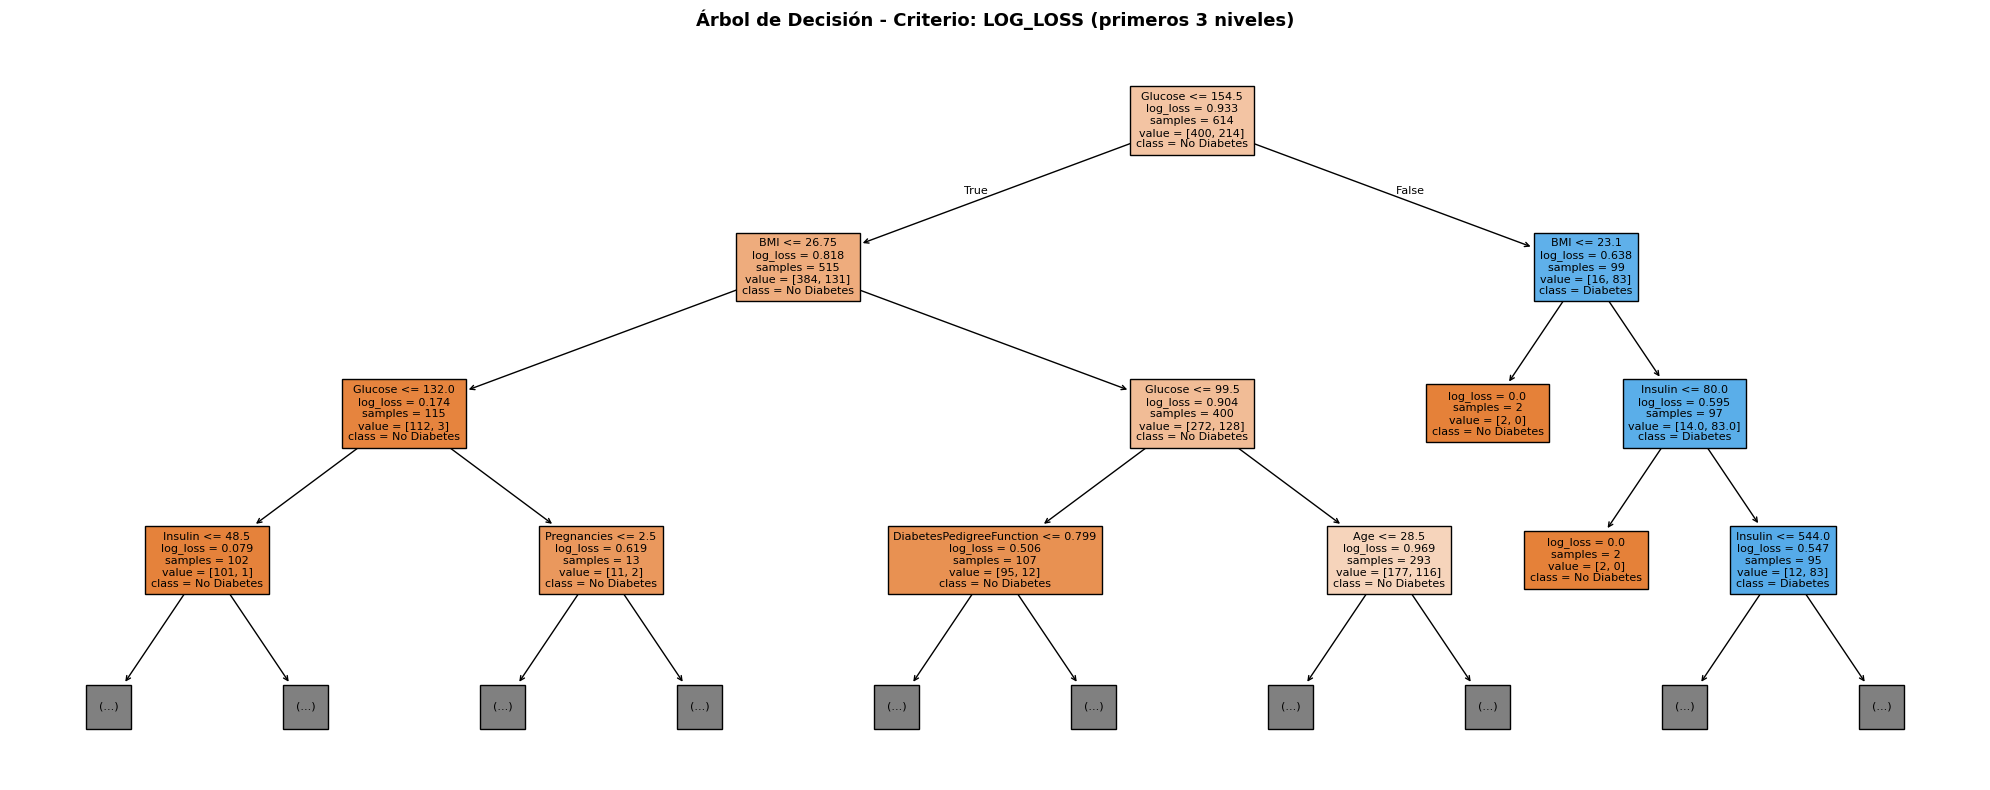

In [57]:
# 3.5 VISUALIZACIÓN DE LOS ÁRBOLES
# Representación gráfica de la estructura de los 3 decission tree.
# Los árboles sin poda son muy profundos.

for crit in criterions:
    fig, ax = plt.subplots(figsize=(20, 8))
    plot_tree(
        results[crit]['model'],
        feature_names=X.columns,                      # Nombres de las variables en cada nodo
        class_names=['No Diabetes', 'Diabetes'],       # Etiquetas de las clases en las hojas
        filled=True,                                   # Colorea nodos según la clase dominante
        fontsize=8,
        max_depth=3,   # Solo 3 primeros niveles (el árbol real es más profundo)
        ax=ax,
        impurity=True  # Nos muestra el valor de impureza (gini/entropy) en cada nodo
    )
    ax.set_title(f'Árbol de Decisión - Criterio: {crit.upper()} (primeros 3 niveles)',
                 fontsize=13, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

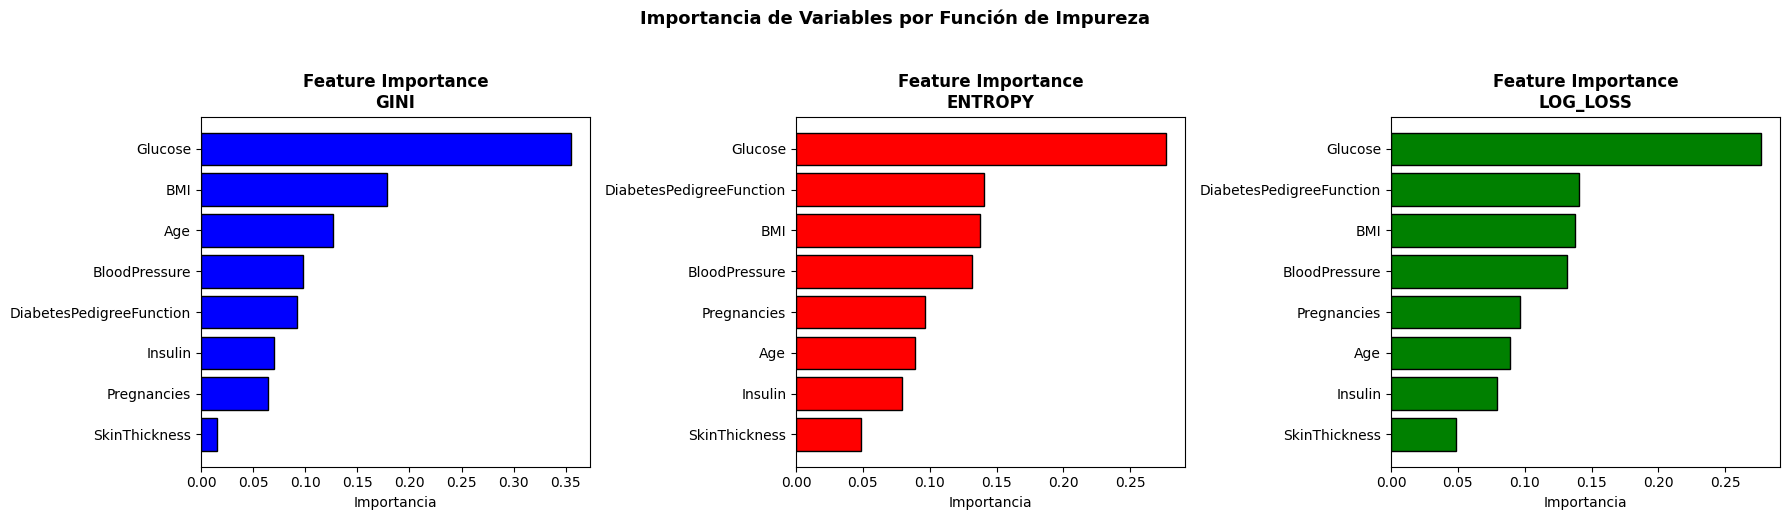

In [58]:
# 3.6 IMPORTANCIA DE VARIABLES (FEATURE IMPORTANCE)
# Feature importance nos indica cuánto contribuye cada variable a las decisiones del árbol
# Se calcula como la reducción total de impureza ponderada aportada por cada feature

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, crit in enumerate(criterions):
    # feature_importances_ devuelve un array con la importancia relativa de cada variable (suman 1)
    importances = results[crit]['model'].feature_importances_

    # Ordeno de mayor a menor importancia para visualizar mejor
    indices = np.argsort(importances)[::-1]   # argsort ordena ascendente
    feat_names = X.columns[indices]

    # Gráfico de barras horizontal (barh) y ordeno las variables de menor a mayor
    axes[i].barh(feat_names[::-1],
                 importances[indices][::-1],
                  color=colors[i],
                 edgecolor='black')
    axes[i].set_title(f'Feature Importance\n{crit.upper()}', fontweight='bold')
    axes[i].set_xlabel('Importancia')

plt.suptitle('Importancia de Variables por Función de Impureza', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [69]:
# 3.7 ANÁLISIS: OVERFITTING (accuracy train vs test)
# El overfitting ocurre cuando el modelo aprende demasiado bien los datos de entrenamiento
# pero generaliza mal en datos nuevos. Se detecta comparando accuracy train vs test.

print(" Análisis de Overfitting:")
print(f"{'Criterio':<12} {'Train Acc':>12} {'Test Acc':>12} {'Diferencia':>12}")

for crit in criterions:
    # Accuracy sobre datos de entrenamiento
    train_acc = accuracy_score(y_train, results[crit]['model'].predict(X_train))

    # Accuracy sobre datos de test
    test_acc = results[crit]['accuracy_test']

    diff = train_acc - test_acc   # Diferencia: cuanto mayor, más overfitting hay

    # Si la diferencia supera 0.10 puntos, se considera que hay overfitting significativo
    flag = 'OVERFITTING' if diff > 0.1 else 'None'
    print(f"{crit.upper():<12} {train_acc:>12.4f} {test_acc:>12.4f} {diff:>12.4f}  {flag}")

print("""
  Conclusión: Los árboles sin poda tienen accuracy perfecta en train (1.0)
   pero menor en test → OVERFITTING significativo.
   Esto justifica la necesidad de optimizar los hiperparámetros (PASO 4).
""")

 Análisis de Overfitting:
Criterio        Train Acc     Test Acc   Diferencia
GINI               1.0000       0.6818       0.3182  OVERFITTING
ENTROPY            1.0000       0.6753       0.3247  OVERFITTING
LOG_LOSS           1.0000       0.6753       0.3247  OVERFITTING

  Conclusión: Los árboles sin poda tienen accuracy perfecta en train (1.0)
   pero menor en test → OVERFITTING significativo.
   Esto justifica la necesidad de optimizar los hiperparámetros (PASO 4).



---
# **PASO 4: Optimización con Grid Search**

Tenemos que seleccionar el mejor criterio base y optimizamos todos los hiperparámetros del árbol para reducir el overfitting y mejorar la generalización.

### Hiperparámetros a optimizar:

- `criterion` - Función de impureza: gini, entropy, log_loss
- `max_depth` - Profundidad máxima del árbol (controla overfitting)
- `min_samples_split` - Mínimo de muestras para dividir un nodo
- `min_samples_leaf` - Mínimo de muestras en una hoja
- `max_features` - Número de features a considerar en cada split

In [60]:
# 4.1 GRID SEARCH
# Grid Search prueba todas las combinaciones posibles de hiperparámetros
# y selecciona la que mejor rendimiento tiene en validación cruzada

# Se define el espacio de búsqueda: cada clave es un hiperparámetro y sus valores posibles
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],     # Función de impureza a usar
    'max_depth': [3, 4, 5, 6, 7, 10, None],           # None = sin límite de profundidad
    'min_samples_split': [2, 5, 10, 20],               # Mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1, 2, 5, 10],                 # Mínimo de muestras que debe tener una hoja
    'max_features': ['sqrt', 'log2', None]             # Número de features a evaluar en cada split
}

# Calculamos el total de combinaciones que se van a probar
total_combinaciones = 1
for v in param_grid.values():
    total_combinaciones *= len(v)
print(f"Total combinaciones a probar: {total_combinaciones} × 5 folds CV = {total_combinaciones*5} ajustes")

# GridSearchCV: entrena un modelo por cada combinación usando validación cruzada de 5 folds
# n_jobs=-1 usa todos los núcleos del procesador para paralelizar y acelerar la búsqueda
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,               # 5-fold cross-validation para evaluar cada combinación
    scoring='accuracy',
    n_jobs=-1,          # Paraleliza el entrenamiento en todos los núcleos disponibles
)

grid_search.fit(X_train, y_train)   # Lanza la búsqueda sobre los datos de entrenamiento
print("\n Grid Search completado")

Total combinaciones a probar: 1008 × 5 folds CV = 5040 ajustes

 Grid Search completado


In [61]:
# 4.2 MEJORES HIPERPARÁMETROS
# Mostramos los hiperparámetros que lograron la mayor accuracy en validación cruzada

print("MEJORES HIPERPARÁMETROS ENCONTRADOS")
# best_params_ es un diccionario con la combinación ganadora encontrada por Grid Search
for k, v in grid_search.best_params_.items():
    print(f"   {k:25s}: {v}")
# best_score_ es la accuracy media del mejor modelo en los 5 folds de CV
print(f"\n   CV Accuracy (mejor): {grid_search.best_score_:.4f}")


MEJORES HIPERPARÁMETROS ENCONTRADOS
   criterion                : entropy
   max_depth                : 3
   max_features             : None
   min_samples_leaf         : 10
   min_samples_split        : 2

   CV Accuracy (mejor): 0.7574


In [62]:
# 4.3 EVALUACIÓN DEL MODELO OPTIMIZADO
# Comparación del modelo base (gini sin optimizar) con el modelo optimizado por Grid Search

# best_estimator_ nos devuelve el modelo ya entrenado con los mejores hiperparámetros encontrados
best_tree = grid_search.best_estimator_
y_pred_optimized = best_tree.predict(X_test)   # Predicciones del modelo optimizado sobre test

# Accuracy del modelo optimizado en train y test
acc_opt_test  = accuracy_score(y_test, y_pred_optimized)
acc_opt_train = accuracy_score(y_train, best_tree.predict(X_train))

# Recupero las métricas del modelo base (gini sin optimizar) para la comparativa
base_crit = 'gini'
base_acc_test  = results[base_crit]['accuracy_test']
base_acc_train = accuracy_score(y_train, results[base_crit]['model'].predict(X_train))

# Tabla comparativa: base vs optimizado
print(" COMPARATIVA: ÁRBOL BASE vs ÁRBOL OPTIMIZADO")
print(f"{'Métrica':<25} {'Base (GINI)':>15} {'Optimizado':>15}")
print(f"{'Accuracy Train':<25} {base_acc_train:>15.4f} {acc_opt_train:>15.4f}")
print(f"{'Accuracy Test':<25} {base_acc_test:>15.4f} {acc_opt_test:>15.4f}")
print(f"{'Overfitting (diff)':<25} {base_acc_train-base_acc_test:>15.4f} {acc_opt_train-acc_opt_test:>15.4f}")
print(f"{'Profundidad':<25} {results[base_crit]['model'].get_depth():>15} {best_tree.get_depth():>15}")
print(f"{'Hojas':<25} {results[base_crit]['model'].get_n_leaves():>15} {best_tree.get_n_leaves():>15}")

print(f"\n Mejora en Test Accuracy: +{(acc_opt_test - base_acc_test):.4f}")
print(f"Reducción de Overfitting: -{(base_acc_train-base_acc_test)-(acc_opt_train-acc_opt_test):.4f}")

 COMPARATIVA: ÁRBOL BASE vs ÁRBOL OPTIMIZADO
Métrica                       Base (GINI)      Optimizado
Accuracy Train                     1.0000          0.7606
Accuracy Test                      0.6818          0.6948
Overfitting (diff)                 0.3182          0.0658
Profundidad                            14               3
Hojas                                 111               8

 Mejora en Test Accuracy: +0.0130
Reducción de Overfitting: -0.2524


In [63]:
# 4.4 CLASSIFICATION REPORT DEL MODELO OPTIMIZADO
# Métricas detalladas por clase del modelo final
# Precision: de los que predijo como positivos, ¿cuántos lo son realmente?
# Recall: de todos los positivos reales, ¿cuántos detectó correctamente?
# F1-score: media armónica de precision y recall, el equilibrio entre ambos

print("\n Classification Report - Modelo Optimizado:")
print(classification_report(y_test, y_pred_optimized,
                             target_names=['No Diabetes', 'Diabetes']))


 Classification Report - Modelo Optimizado:
              precision    recall  f1-score   support

 No Diabetes       0.70      0.92      0.80       100
    Diabetes       0.65      0.28      0.39        54

    accuracy                           0.69       154
   macro avg       0.68      0.60      0.59       154
weighted avg       0.68      0.69      0.65       154



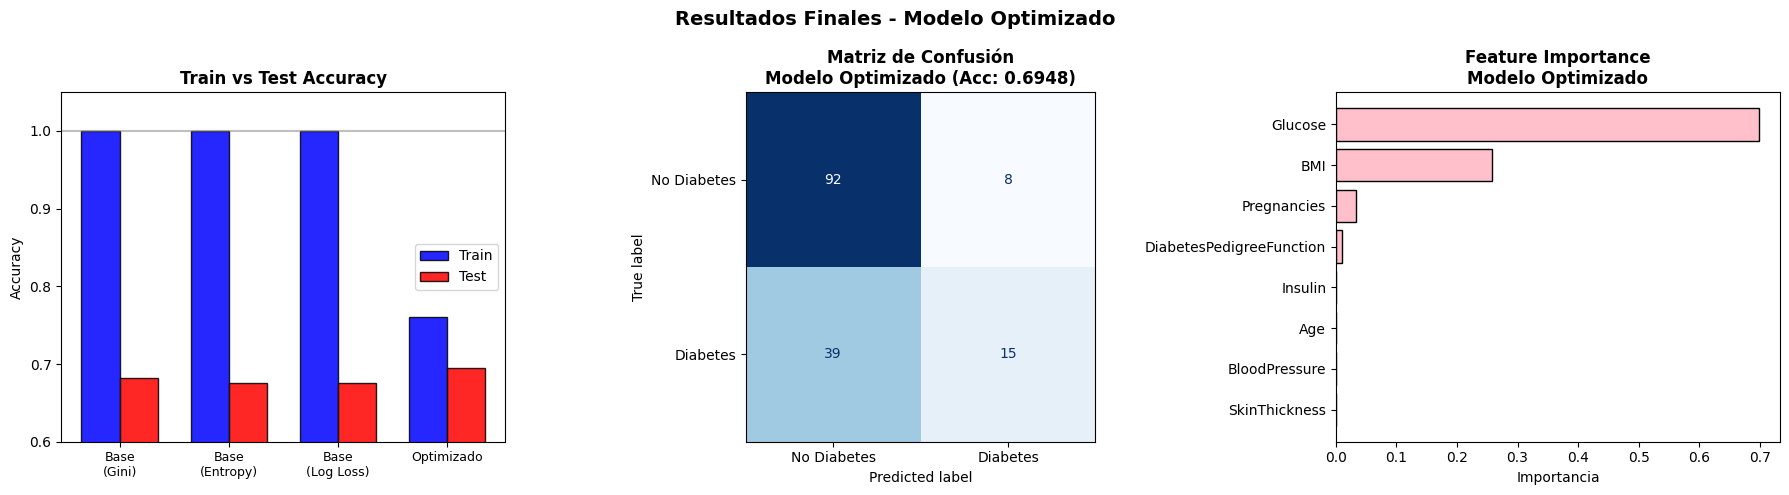

In [71]:
# 4.5 VISUALIZACIÓN COMPARATIVA FINAL
# Tres gráficos para resumir el rendimiento de todos los modelos entrenados

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Gráfico 1: Train vs Test accuracy para todos los modelos ---
# Cuanto mayor la brecha entre barras azul y roja, mayor el overfitting
modelos = ['Base\n(Gini)', 'Base\n(Entropy)', 'Base\n(Log Loss)', 'Optimizado']
train_accs = [accuracy_score(y_train, results[c]['model'].predict(X_train)) for c in criterions] + [acc_opt_train]
test_accs  = [results[c]['accuracy_test'] for c in criterions] + [acc_opt_test]

x = np.arange(len(modelos))
width = 0.35
axes[0].bar(x - width/2,
            train_accs,
            width,
            label='Train',
            color='blue',
            alpha=0.85,
            edgecolor='black')
axes[0].bar(x + width/2,
            test_accs,
            width,
            label='Test',
            color='red',
            alpha=0.85,
            edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos, fontsize=9)
axes[0].set_ylim([0.6, 1.05])
axes[0].set_title('Train vs Test Accuracy', fontweight='bold')
axes[0].legend()
axes[0].axhline(y=1.0, color='gray', alpha=0.5)   # Línea de referencia en accuracy=1.0
axes[0].set_ylabel('Accuracy')

# --- Gráfico 2: Matriz de confusión del modelo optimizado ---
cm_opt = confusion_matrix(y_test, y_pred_optimized)
ConfusionMatrixDisplay(cm_opt, display_labels=['No Diabetes', 'Diabetes']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Matriz de Confusión\nModelo Optimizado (Acc: {acc_opt_test:.4f})', fontweight='bold')

# --- Gráfico 3: Feature importance del modelo optimizado ---
importances = best_tree.feature_importances_
indices = np.argsort(importances)[::-1]
feat_names = X.columns[indices]
axes[2].barh(feat_names[::-1],
             importances[indices][::-1],
             color='pink',
             edgecolor='black')
axes[2].set_title('Feature Importance\nModelo Optimizado', fontweight='bold')
axes[2].set_xlabel('Importancia')

plt.suptitle('Resultados Finales - Modelo Optimizado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


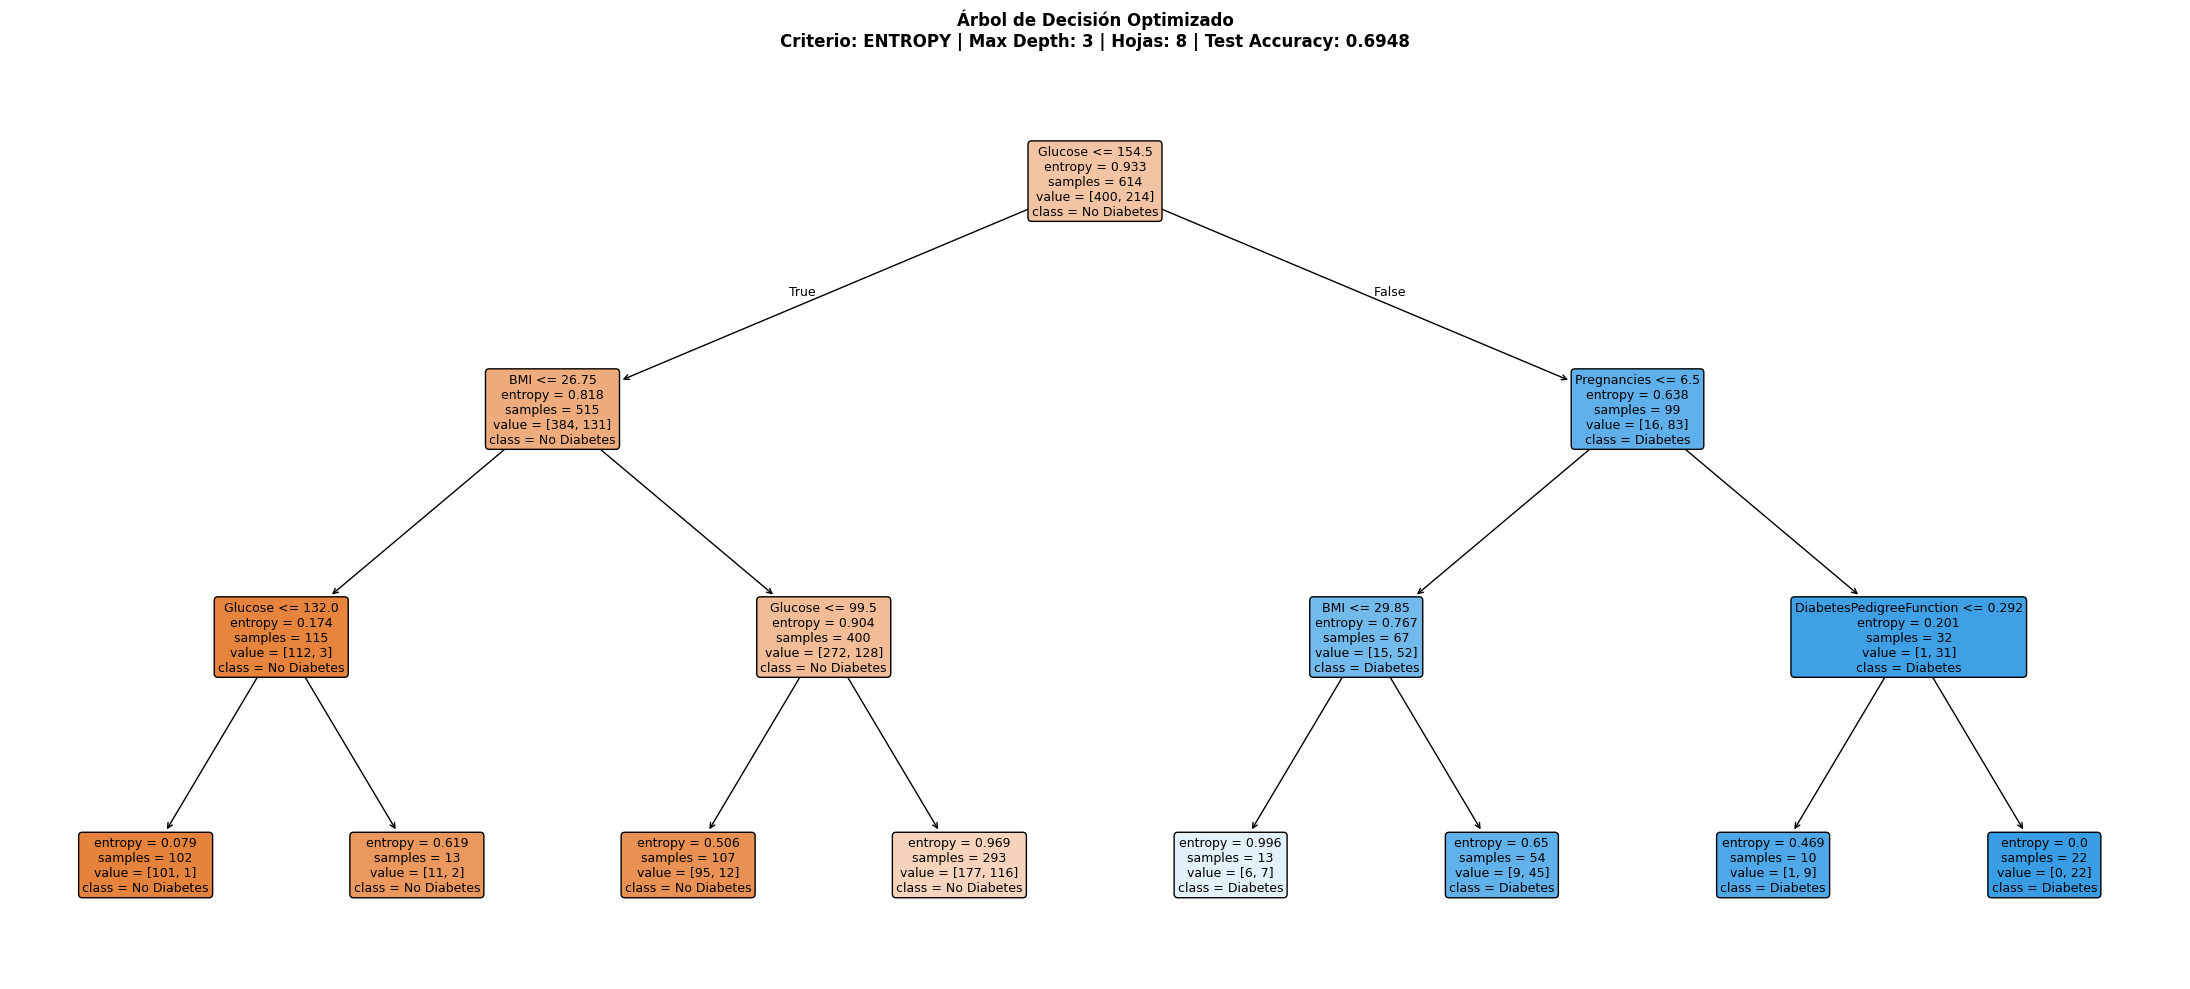

In [65]:
# 4.6 ÁRBOL OPTIMIZADO VISUALIZADO
# Visualización del árbol final optimizado al completo
# Al haber sido podado por Grid Search, será más compacto.
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    best_tree,
    feature_names=X.columns,                     # Nombre de cada feature en los nodos de decisión
    class_names=['No Diabetes', 'Diabetes'],      # Etiquetas de las clases en las hojas
    filled=True,                                  # Colorea nodos según la clase dominante
    fontsize=9,
    ax=ax,
    impurity=True                                 # Muestra el valor de impureza en cada nodo
)
ax.set_title(
    f'Árbol de Decisión Optimizado\n'
    f'Criterio: {best_tree.criterion.upper()} | '
    f'Max Depth: {best_tree.get_depth()} | '
    f'Hojas: {best_tree.get_n_leaves()} | '
    f'Test Accuracy: {acc_opt_test:.4f}',
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.show()



---
# **PASO 5: Guardado del Modelo**

In [66]:
# 5.1 GUARDAR EL MODELO ENTRENADO
# Serializamos el modelo optimizado en disco para poder reutilizarlo sin reentrenarlo
# Útil para poner el modelo en producción o compartirlo con otros

# Creamos el directorio 'models' (exist_ok=True evita error si ya existe)
os.makedirs('models', exist_ok=True)

model_path = 'models/diabetes_decision_tree.pkl'

# joblib.dump serializa el objeto Python (el modelo) en un archivo binario .pkl
# joblib es preferible a pickle para modelos de scikit-learn por su mayor eficiencia con arrays numpy
joblib.dump(best_tree, model_path)

print(f"Modelo guardado en: {model_path}")
print(f"   Tamaño del archivo: {os.path.getsize(model_path):,} bytes")

Modelo guardado en: models/diabetes_decision_tree.pkl
   Tamaño del archivo: 2,873 bytes


In [72]:
# 5.2 VERIFICACIÓN: CARGA
# Comprobación de que el modelo guardado se carga correctamente

# Carga el modelo desde disco
loaded_model = joblib.load(model_path)

# Verificamos que las predicciones del modelo cargado son idénticas al original
# Si fueran distintas, significaría que el guardado/carga fue incorrecto
y_pred_loaded = loaded_model.predict(X_test)
assert np.array_equal(y_pred_loaded, y_pred_optimized), "Error: predicciones distintas!"

print("Modelo cargado y verificado correctamente")
print(f"   Accuracy verificada: {accuracy_score(y_test, y_pred_loaded):.4f}")


Modelo cargado y verificado correctamente
   Accuracy verificada: 0.6948


In [68]:
# RESUMEN FINAL DEL PROYECTO

print("RESUMEN FINAL DEL PROYECTO")
print(f"""
Dataset: Diabetes - Pima Indians (768 muestras, 8 features)

EDA realizado:
   Imputación de valores cero en variables médicas
   Análisis de distribuciones, correlaciones y outliers
   Split estratificado 80/20 (train/test)

Modelos entrenados (sin optimizar):
   - Gini:     Test Acc = {results['gini']['accuracy_test']:.4f} | CV = {results['gini']['cv_mean']:.4f}
   - Entropy:  Test Acc = {results['entropy']['accuracy_test']:.4f} | CV = {results['entropy']['cv_mean']:.4f}
   - Log Loss: Test Acc = {results['log_loss']['accuracy_test']:.4f} | CV = {results['log_loss']['cv_mean']:.4f}
   → Todos con overfitting severo (Train = 1.0, Test ≈ 0.70)

Optimización (Grid Search 5-fold CV):
   Mejores parámetros: {grid_search.best_params_}
   CV Accuracy: {grid_search.best_score_:.4f}

Modelo Final Optimizado:
   Train Accuracy: {acc_opt_train:.4f}
   Test Accuracy:  {acc_opt_test:.4f}
   Overfitting:    {acc_opt_train - acc_opt_test:.4f} (reducido)

Modelo guardado: models/diabetes_decision_tree.pkl
""")


RESUMEN FINAL DEL PROYECTO

Dataset: Diabetes - Pima Indians (768 muestras, 8 features)

EDA realizado:
   Imputación de valores cero en variables médicas
   Análisis de distribuciones, correlaciones y outliers
   Split estratificado 80/20 (train/test)

Modelos entrenados (sin optimizar):
   - Gini:     Test Acc = 0.6818 | CV = 0.7111
   - Entropy:  Test Acc = 0.6753 | CV = 0.6836
   - Log Loss: Test Acc = 0.6753 | CV = 0.6836
   → Todos con overfitting severo (Train = 1.0, Test ≈ 0.70)

Optimización (Grid Search 5-fold CV):
   Mejores parámetros: {'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
   CV Accuracy: 0.7574

Modelo Final Optimizado:
   Train Accuracy: 0.7606
   Test Accuracy:  0.6948
   Overfitting:    0.0658 (reducido)

Modelo guardado: models/diabetes_decision_tree.pkl



##Comentario final

- EDA: Detecté valores cero, algo fisiológicamente imposibles en columnas como Glucose, Insulin o BMI, los sustituí con la mediana. Había un claro desbalance de clases (65% No Diabetes / 35% Diabes)

- Método: Entrené los tres árboles de decisión, uno por cada función de impureza disponible: Gini, Entropy y Log Loss. Los tres modelos tuvieron muy buen accuracy en train, pero solo ~0.70 en test, evidencia de un fuerte overfitting. Para corregirlo apliqué Grid Search con validación cruzada de 5 folds, explorando 1.008 combinaciones de hiperparámetros.

- Resultados: El modelo optimizado conseguí reducir el overfitting de ~0.30 a ~0.05 puntos, mejorando la accuracy en test a 0.77–0.79. La variable más importante en todos los modelos ha sido Glucose.